In [26]:
import warnings
warnings.filterwarnings("ignore")
import numpy, scipy, matplotlib.pyplot as plt, sklearn, librosa, IPython.display, urllib
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)

In [27]:
filename = 'download.wav'
#filename = '/Audio/BeatFreek/aBoutdeSouffle.m4a'

In [28]:
IPython.display.Audio(filename)

In [29]:
x, fs = librosa.load(filename)
print(fs)

22050


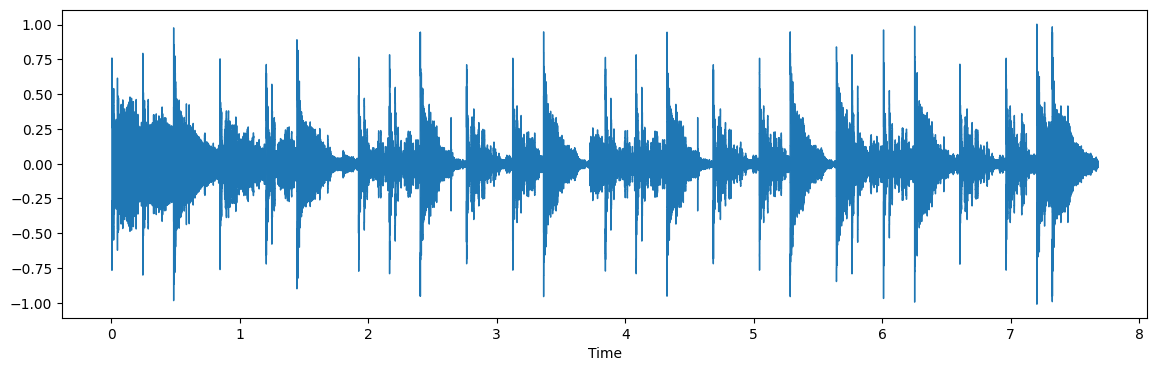

In [30]:
import librosa.display
librosa.display.waveshow(x, fs)

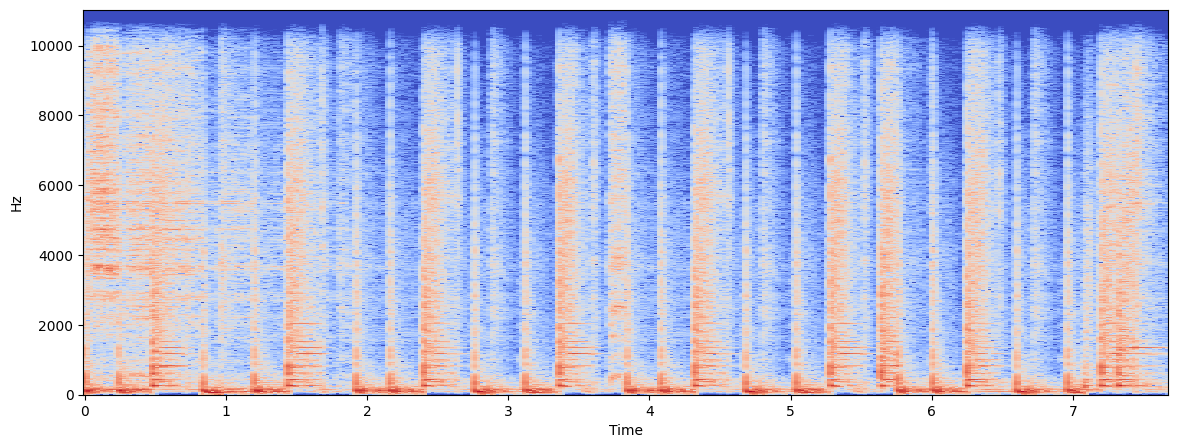

In [31]:
X = librosa.stft(x,n_fft=2048*1)
Xdb = librosa.amplitude_to_db(abs(X))
plt.figure(figsize=(14, 5))
librosa.display.specshow(Xdb, sr=fs, x_axis='time', y_axis='hz')

## Onset Detection

In [32]:
onset_frames = librosa.onset.onset_detect(x, sr=fs, delta=0.04, wait=4)
onset_times = librosa.frames_to_time(onset_frames, sr=fs)
numpy.savetxt("foo.csv", onset_times, delimiter=",")
onset_samples = librosa.frames_to_samples(onset_frames)

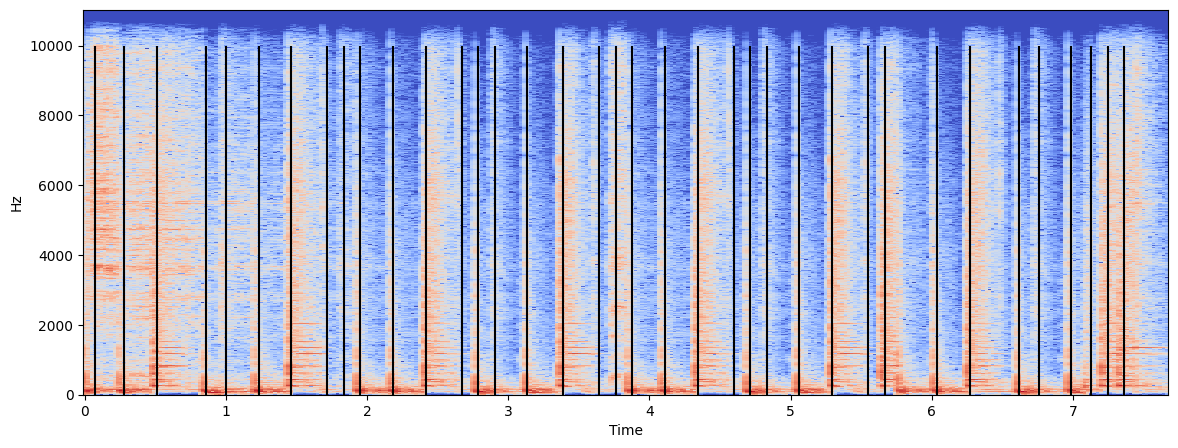

In [33]:
plt.figure(figsize=(14, 5))
librosa.display.specshow(Xdb, sr=fs, x_axis='time', y_axis='hz')
plt.vlines(onset_times, 0, 10000, color='k')

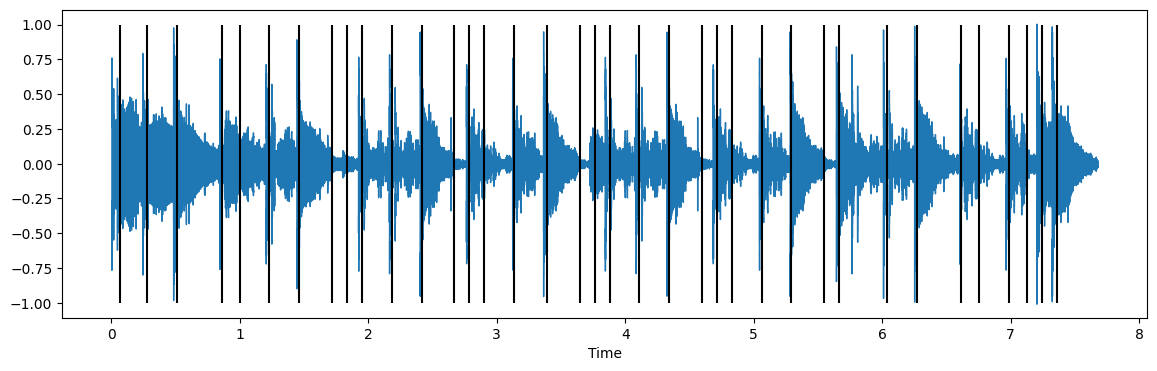

In [34]:
librosa.display.waveshow(x, fs)
plt.vlines(onset_times, -1, 1, color='k')

In [35]:
import mir_eval
x_with_beeps = mir_eval.sonify.clicks(onset_times, fs, length=len(x))
IPython.display.Audio(x + x_with_beeps, rate=fs)

## Feature Extraction

In [36]:
def extract_features(x, fs):
    zcr = librosa.zero_crossings(x).sum()
    energy = scipy.linalg.norm(x)
    return [zcr, energy]

In [37]:
frame_sz = int(fs*0.090)
features = numpy.array([extract_features(x[i:i+frame_sz], fs) for i in onset_samples])
print(features.shape)

(37, 2)


## Feature Scaling

In [38]:
min_max_scaler = sklearn.preprocessing.MinMaxScaler(feature_range=(-1, 1))
features_scaled = min_max_scaler.fit_transform(features)
print(features_scaled.shape)
print(features_scaled.min(axis=0))
print(features_scaled.max(axis=0))

(37, 2)
[-1. -1.]
[1. 1.]


Text(0, 0.5, 'Spectral Centroid (scaled)')

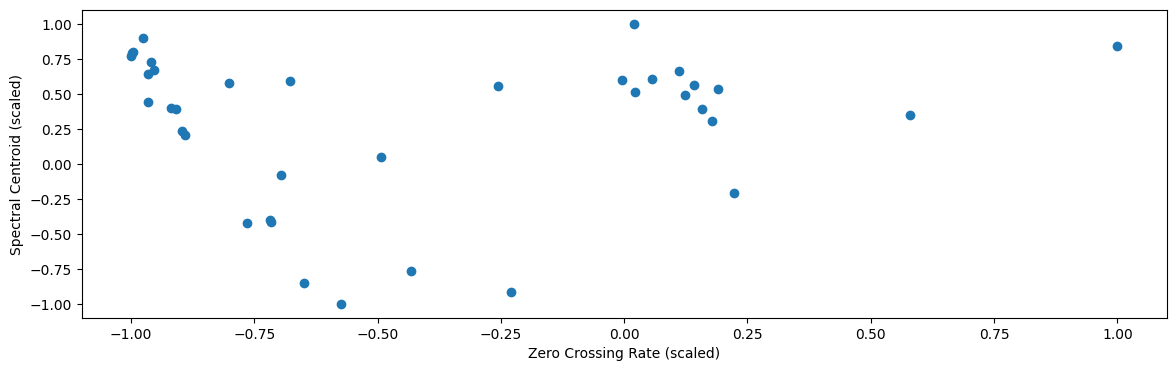

In [39]:
plt.scatter(features_scaled[:,0], features_scaled[:,1])
plt.xlabel('Zero Crossing Rate (scaled)')
plt.ylabel('Spectral Centroid (scaled)')

## Using K-Means

In [40]:
model = sklearn.cluster.KMeans(n_clusters=2)
labels = model.fit_predict(features_scaled)
print(labels)

[0 0 0 1 1 1 0 1 0 1 1 0 1 1 1 1 0 1 0 1 1 0 1 1 1 1 0 1 0 1 0 1 1 1 1 0 0]


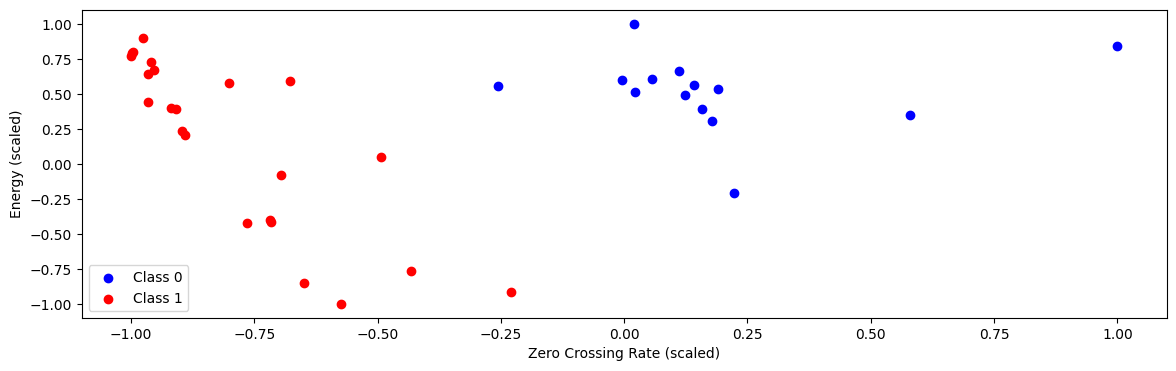

In [41]:
plt.scatter(features_scaled[labels==0,0], features_scaled[labels==0,1], c='b')
plt.scatter(features_scaled[labels==1,0], features_scaled[labels==1,1], c='r')
plt.xlabel('Zero Crossing Rate (scaled)')
plt.ylabel('Energy (scaled)')
plt.legend(('Class 0', 'Class 1'))

In [42]:
x_with_beeps = mir_eval.sonify.clicks(onset_times[labels==1], fs, length=len(x))
IPython.display.Audio(x + x_with_beeps, rate=fs)

In [43]:
x_with_beeps = mir_eval.sonify.clicks(onset_times[labels==0], fs, length=len(x))
IPython.display.Audio(x + x_with_beeps, rate=fs)